In [3]:
from pathlib import Path
import sys

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "raw"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))


In [4]:
%config InlineBackend.figure_format = 'retina'
from collections import Counter
from pprint import pprint
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

from preprocessing import (
    ensure_nltk_resource,
    lemmatize_text,
    preprocess_text,
    stem_text,
)


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/alexandre/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/alexandre/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")


# Financial Tweet Sentiment Workflow

This notebook is the single end-to-end project artifact for exploration, splitting, and preprocessing.

## Table of Contents

- [1. Data Exploration](#1.-Data-Exploration)
- [2. Train/Validation Split](#2.-Train/Validation-Split)
- [3. Text Preprocessing](#3.-Text-Preprocessing)
- [4. Feature Engineering](#4.-Feature-Engineering)
- [5. Classification Models](#5.-Classification-Models)
- [6. Evaluation and Analysis](#6.-Evaluation-and-Analysis)


# 1. Data Exploration


In [6]:
# --- Class proportions --- #
print(train["label"].value_counts(normalize=True))

label
2    0.647386
1    0.201509
0    0.151106
Name: proportion, dtype: float64


In [7]:
train.head(10)

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


In [8]:
print("Dimensions of train dataset:", train.shape)
print("Dimensions of test dataset:", test.shape)

Dimensions of train dataset: (9543, 2)
Dimensions of test dataset: (2388, 2)


In [9]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 149.2 KB
None


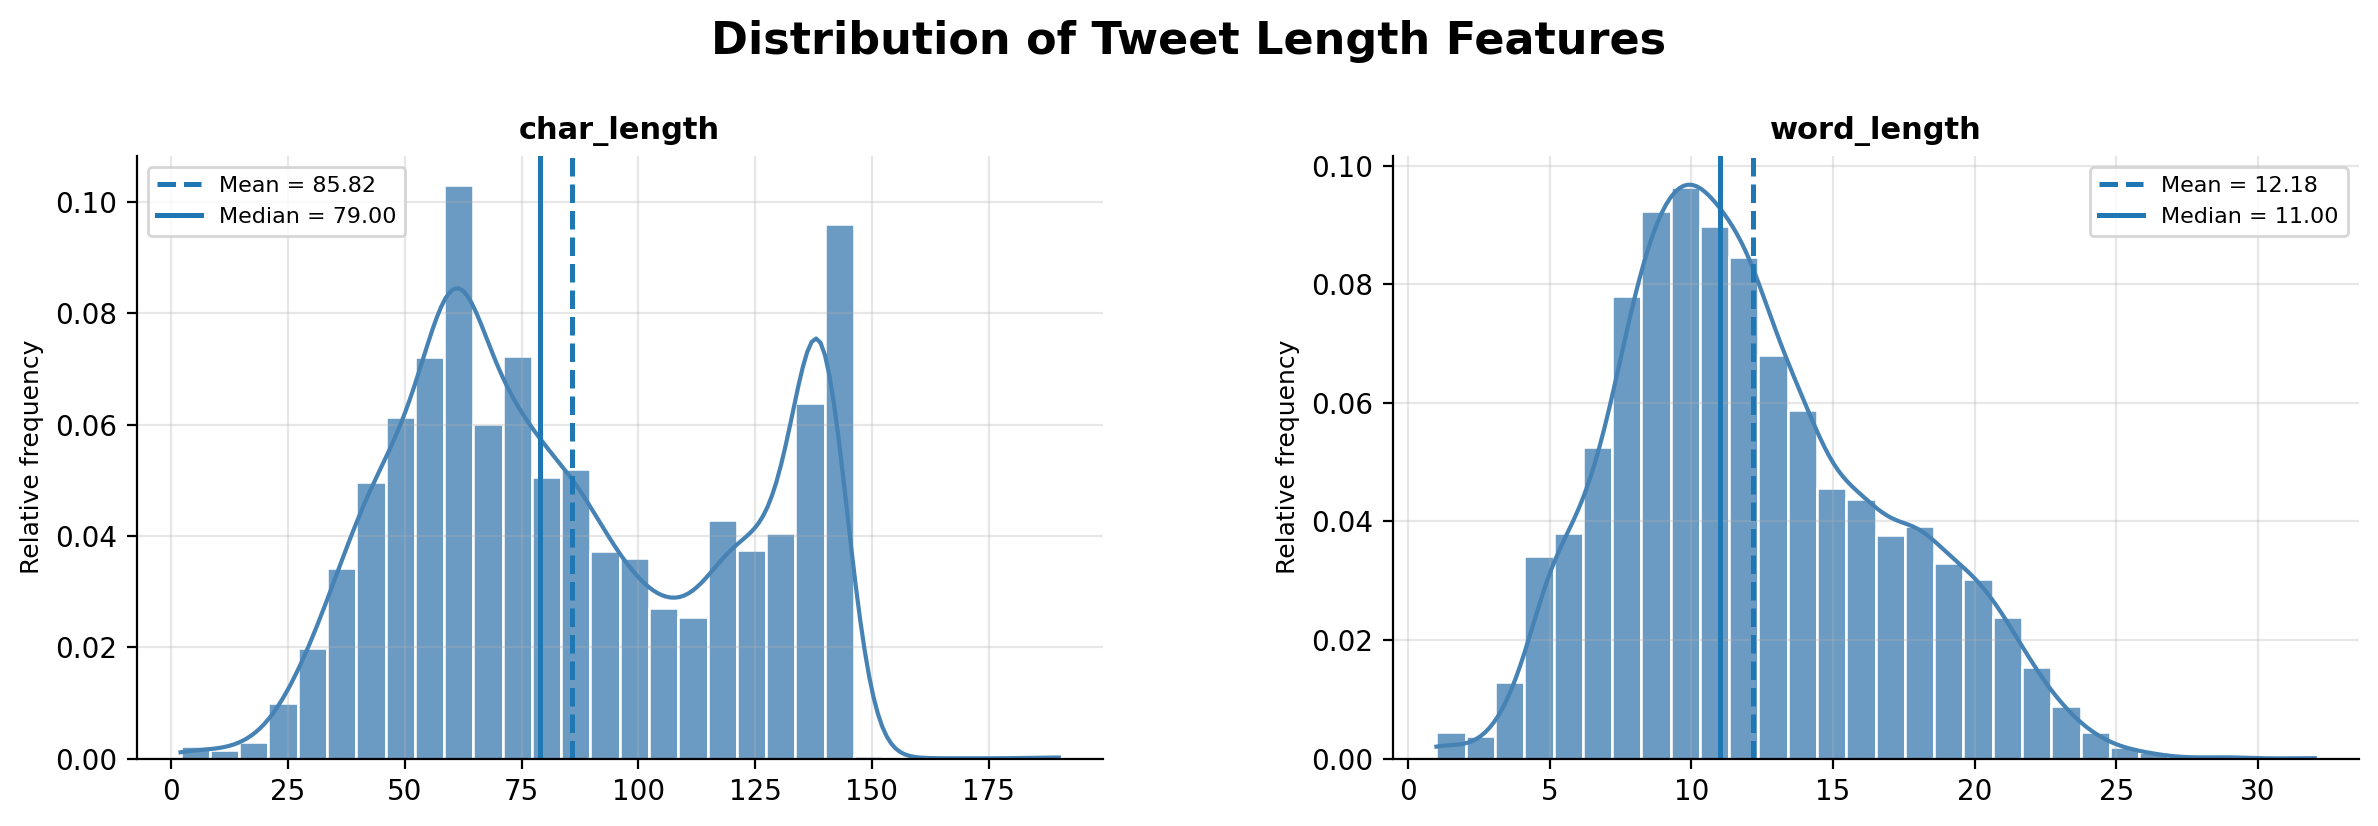

Skewness:
word_length    0.453958
char_length    0.217022
dtype: float64


In [10]:
# --- Create text-length features once for EDA --- #
eda_train = train.assign(
    char_length=train["text"].str.len(),
    word_length=train["text"].str.split().str.len(),
)

numeric_cols = ["char_length", "word_length"]

n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))

axes = axes.flatten() if len(numeric_cols) > 1 else [axes]

for i, col in enumerate(numeric_cols):
    mean = eda_train[col].mean()
    median = eda_train[col].median()

    sns.histplot(
        data=eda_train,
        x=col,
        ax=axes[i],
        bins=30,
        kde=True,
        stat="probability",
        color="steelblue",
        edgecolor="white",
        alpha=0.8,
    )

    axes[i].axvline(mean, linestyle="--", linewidth=1.8, label=f"Mean = {mean:.2f}")
    axes[i].axvline(
        median, linestyle="-", linewidth=1.8, label=f"Median = {median:.2f}"
    )
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Relative frequency", fontsize=9)
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=8)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Distribution of Tweet Length Features", fontsize=16, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.subplots_adjust(top=0.85, hspace=0.4, wspace=0.3)
sns.despine()
plt.show()

print("Skewness:")
print(eda_train[numeric_cols].skew().sort_values(ascending=False))


The distributions of tweet length measured in both characters and words indicate that the corpus is predominantly composed of short texts, with a median length of 79 characters and 11 words per tweet. This finding is consistent with the nature of financial tweets, which frequently resemble concise news headlines, analyst recommendations, or short market updates. Both distributions exhibit a slight positive skew, as evidenced by the mean values exceeding the corresponding medians and further supported by the skewness coefficients of 0.217 for character length and 0.454 for word length. These values indicate only a moderate departure from symmetry, suggesting that while the corpus contains some longer tweets, they represent a relatively small proportion of the observations. Consequently, most tweets remain concentrated around the central region of the distributions, with only a limited number of messages contributing to the right tail and increasing the average tweet length.
Moreover, an additional observation can be made regarding the character-length distribution, which appears to display a bimodal structure. One concentration of tweets is observed around 60–80 characters, while a second concentration occurs around 130–145 characters. This pattern may indicate the coexistence of different types of financial tweets within the corpus, such as brief market commentary and longer headline-style messages containing additional information, ticker symbols, hashtags, or links.


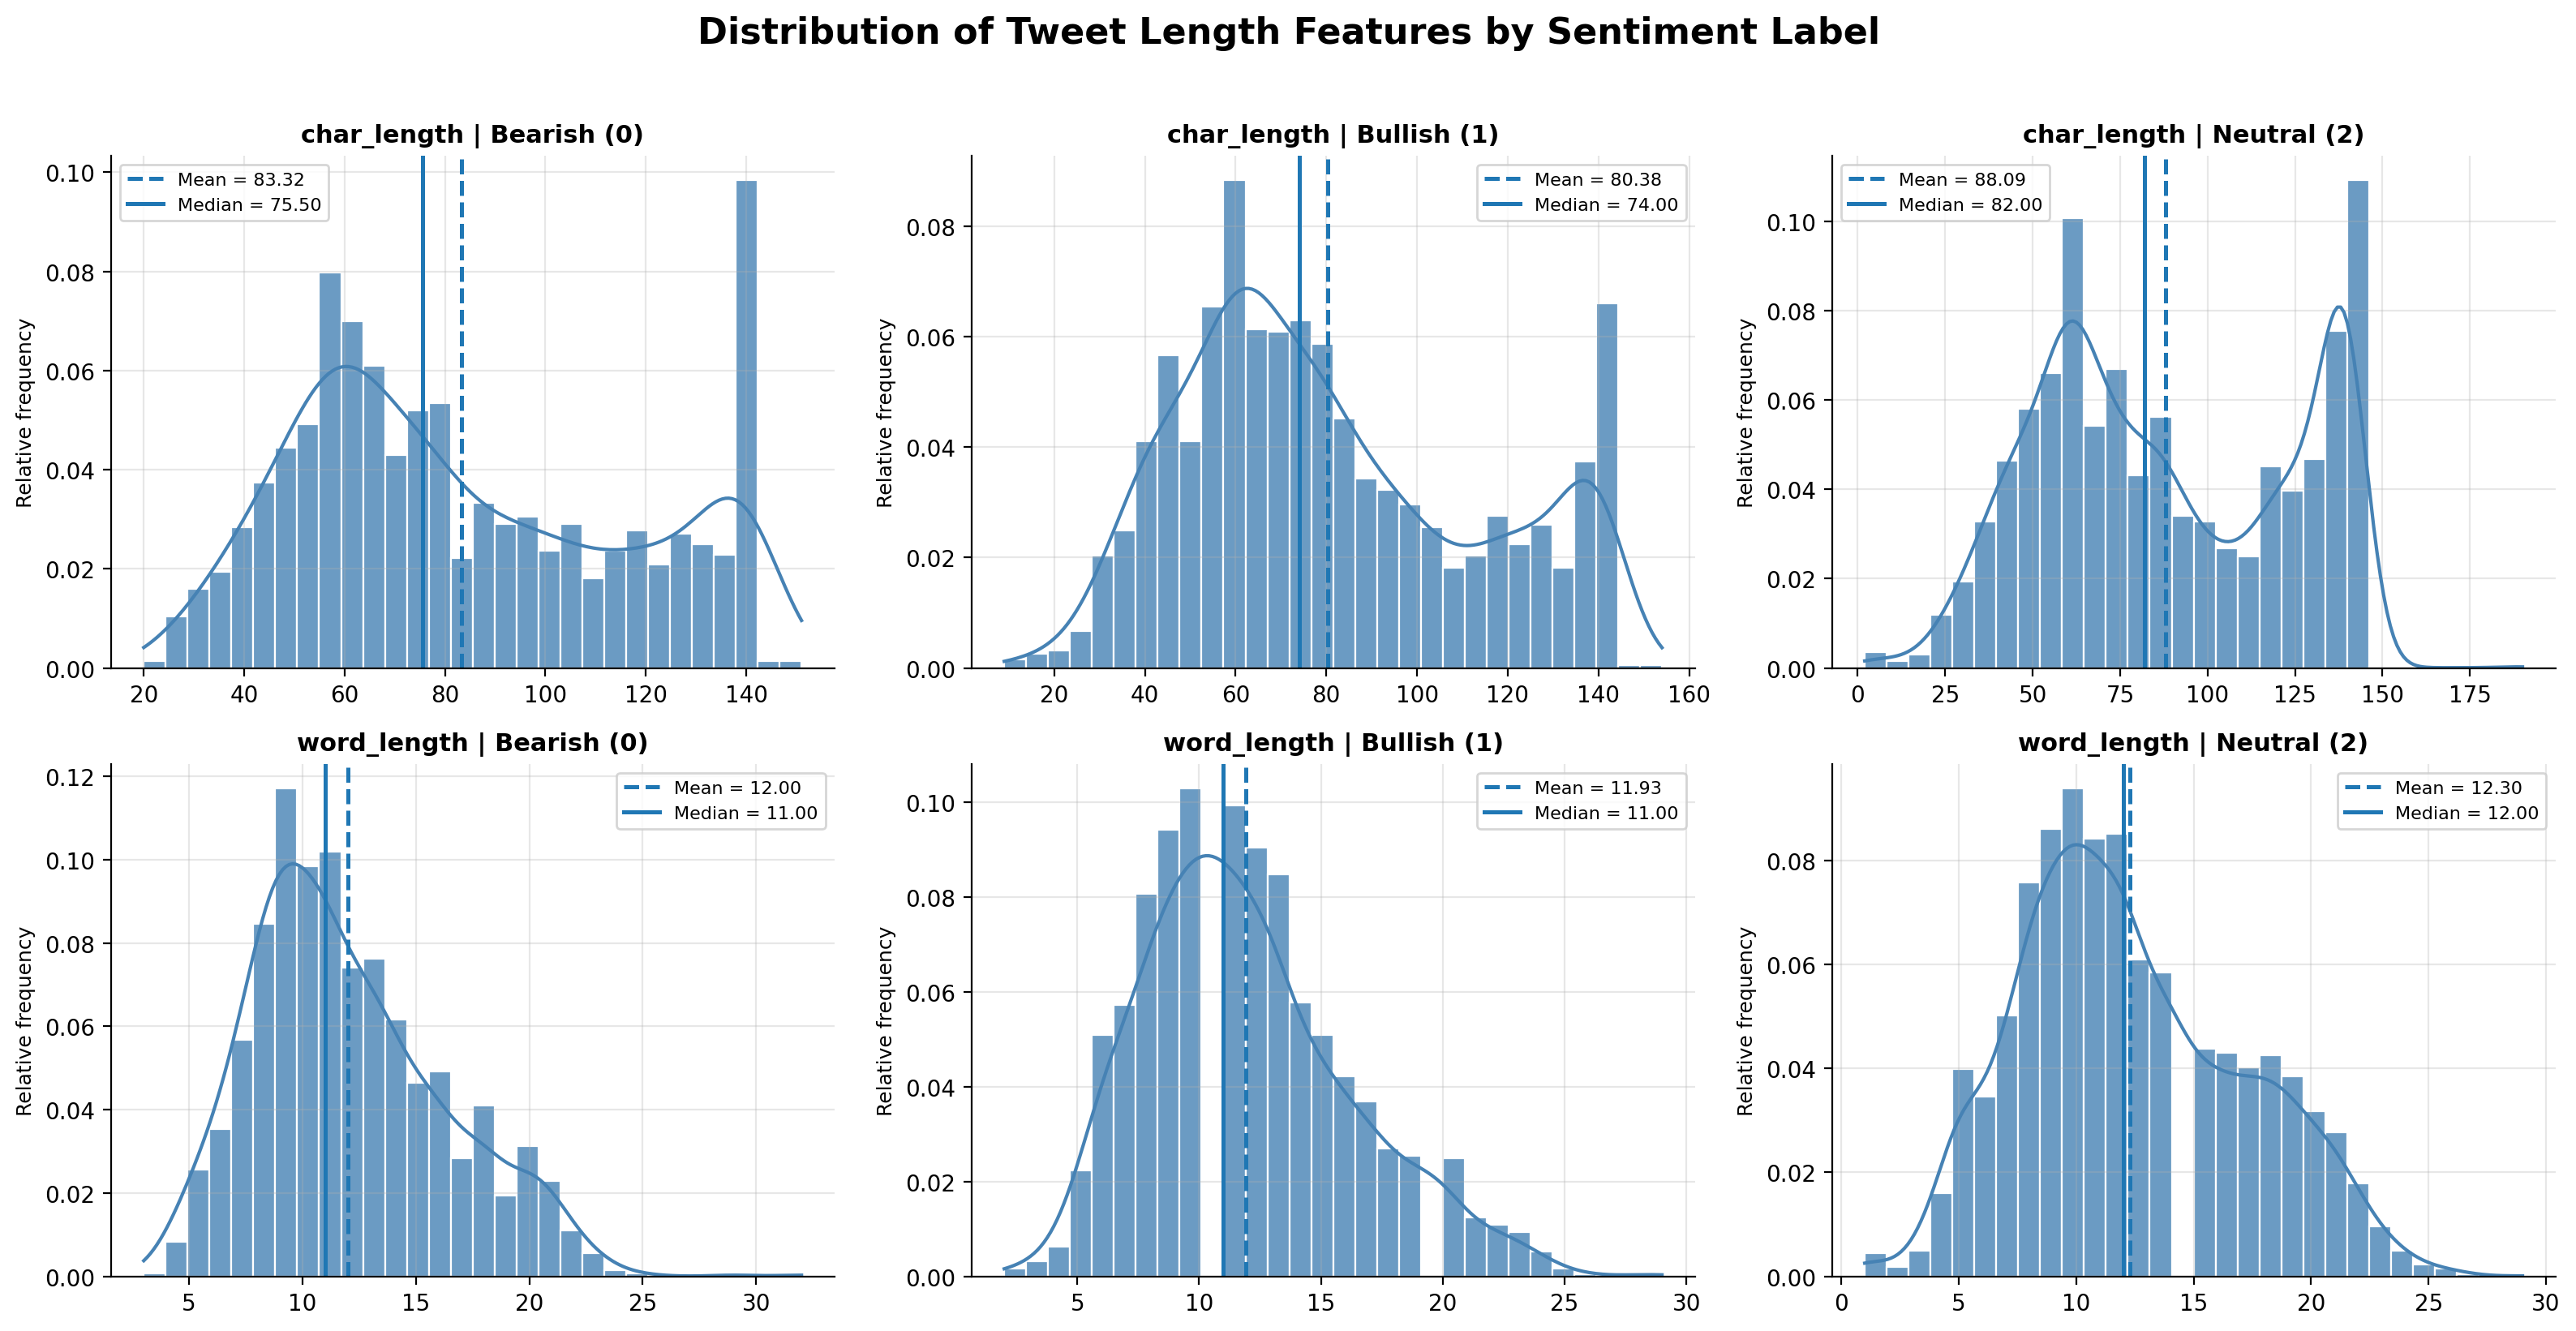

In [11]:
length_cols = ["char_length", "word_length"]

label_map = {0: "Bearish (0)", 1: "Bullish (1)", 2: "Neutral (2)"}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, col in enumerate(length_cols):
    for j, label in enumerate(sorted(eda_train["label"].unique())):
        ax = axes[row, j]
        subset = eda_train.query("label == @label")

        mean = subset[col].mean()
        median = subset[col].median()

        sns.histplot(
            data=subset,
            x=col,
            ax=ax,
            bins=30,
            kde=True,
            stat="probability",
            color="steelblue",
            edgecolor="white",
            alpha=0.8,
        )

        ax.axvline(mean, linestyle="--", linewidth=1.8, label=f"Mean = {mean:.2f}")
        ax.axvline(median, linestyle="-", linewidth=1.8, label=f"Median = {median:.2f}")
        ax.set_title(f"{col} | {label_map[label]}", fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Relative frequency", fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

fig.suptitle(
    "Distribution of Tweet Length Features by Sentiment Label",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

sns.despine()
plt.tight_layout()
plt.show()


To further investigate whether tweet length varies across sentiment categories, the distributions of character length and word length were examined separately for Bearish, Bullish, and Neutral tweets. Overall, the results reveal a high degree of similarity across the three sentiment classes. The mean and median values remain relatively stable, with average character lengths ranging from approximately 80 to 88 characters and average word counts ranging from 12 to 12.3 words. These findings suggest that tweet length is largely independent of sentiment and is therefore unlikely to serve as a strong predictive feature on its own.

The distributions of character length exhibit a similar shape across all sentiment classes, including the bimodal pattern previously observed in the overall corpus. In each category, one concentration of tweets appears around 60–80 characters, while a second concentration is observed near 130–145 characters. The persistence of this structure across Bearish, Bullish, and Neutral tweets indicates that the bimodality is more likely related to different styles of financial communication than to sentiment itself. For example, both positive and negative market commentary may be expressed either as short analyst statements or as longer headline-style messages containing additional contextual information.

A comparable pattern is observed for word length. All three sentiment classes display positively skewed distributions centred around 10–12 words per tweet. While Neutral tweets appear marginally longer on average than Bearish and Bullish tweets, the differences are relatively small and do not indicate a substantial separation between classes. The considerable overlap among the distributions further suggests that sentiment classification cannot be reliably achieved through length-based features alone.

Taken together, these results indicate that structural characteristics such as tweet length provide limited discriminatory power for the sentiment classification task. Consequently, successful classification is expected to depend primarily on the semantic content of the tweets rather than on simple quantitative measures of text length.


In [12]:
for label in sorted(train["label"].unique()):
    subset = train.query("label == @label")

    words = " ".join(subset["text"]).lower().split()

    print(f"Label {label}")
    pprint(Counter(words).most_common(20))


Label 0
[('to', 378),
 ('the', 316),
 ('in', 263),
 ('of', 232),
 ('on', 222),
 ('-', 210),
 ('as', 174),
 ('after', 171),
 ('a', 166),
 ('at', 140),
 ('stock', 130),
 ('for', 130),
 ('down', 127),
 ('and', 121),
 ('from', 102),
 ('is', 102),
 ('by', 93),
 ('are', 92),
 ('misses', 85),
 ('u.s.', 79)]
Label 1
[('to', 488),
 ('on', 386),
 ('the', 344),
 ('-', 317),
 ('in', 298),
 ('up', 255),
 ('stock', 231),
 ('a', 222),
 ('for', 209),
 ('at', 208),
 ('of', 189),
 ('as', 170),
 ('after', 165),
 ('beats', 161),
 ('and', 150),
 ('price', 132),
 ('from', 126),
 ('by', 125),
 ('target', 116),
 ('shares', 110)]
Label 2
[('the', 1836),
 ('to', 1759),
 ('of', 1239),
 ('in', 1017),
 ('a', 923),
 ('for', 872),
 ('-', 863),
 ('on', 747),
 ('and', 740),
 ('is', 655),
 ('with', 363),
 (':', 343),
 ('results', 307),
 ('at', 294),
 ('#stock', 283),
 ('new', 282),
 ('as', 261),
 ('are', 246),
 ('this', 244),
 ('earnings', 239)]


An analysis of the most frequent terms reveals clear differences in the vocabulary associated with each sentiment class. Bearish tweets are characterized by negative financial expressions such as down and misses, reflecting adverse market performance, earnings disappointments, or negative analyst assessments. In contrast, Bullish tweets frequently contain terms such as up, beats, price, and target, which are commonly associated with positive market sentiment, earnings outperformance, and upward price expectations. Neutral tweets are dominated by more informational and descriptive terms, including results, earnings, new, and #stock, suggesting a focus on reporting financial events rather than expressing an explicitly positive or negative opinion. Overall, the vocabulary distribution indicates that sentiment classes are primarily distinguished by their semantic content, supporting the use of feature engineering techniques capable of capturing contextual and domain-specific meaning.


In [13]:
eda_train = eda_train.assign(
    num_tickers=eda_train["text"].str.count(r"\$[A-Za-z]+"),
    has_url=eda_train["text"].str.contains(r"http\S+|www\S+", regex=True),
    has_mention=eda_train["text"].str.contains(r"@\w+", regex=True),
)

eda_train.head()


,text,label,char_length,word_length,num_tickers,has_url,has_mention
0,$BYND - JPMorgan reels in expectations on Beyo...,0,77,10,1,True,False
1,$CCL $RCL - Nomura points to bookings weakness...,0,102,14,2,True,False
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,94,14,1,True,False
3,$ESS: BTIG Research cuts to Neutral https://t....,0,59,7,1,True,False
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,71,10,1,True,False


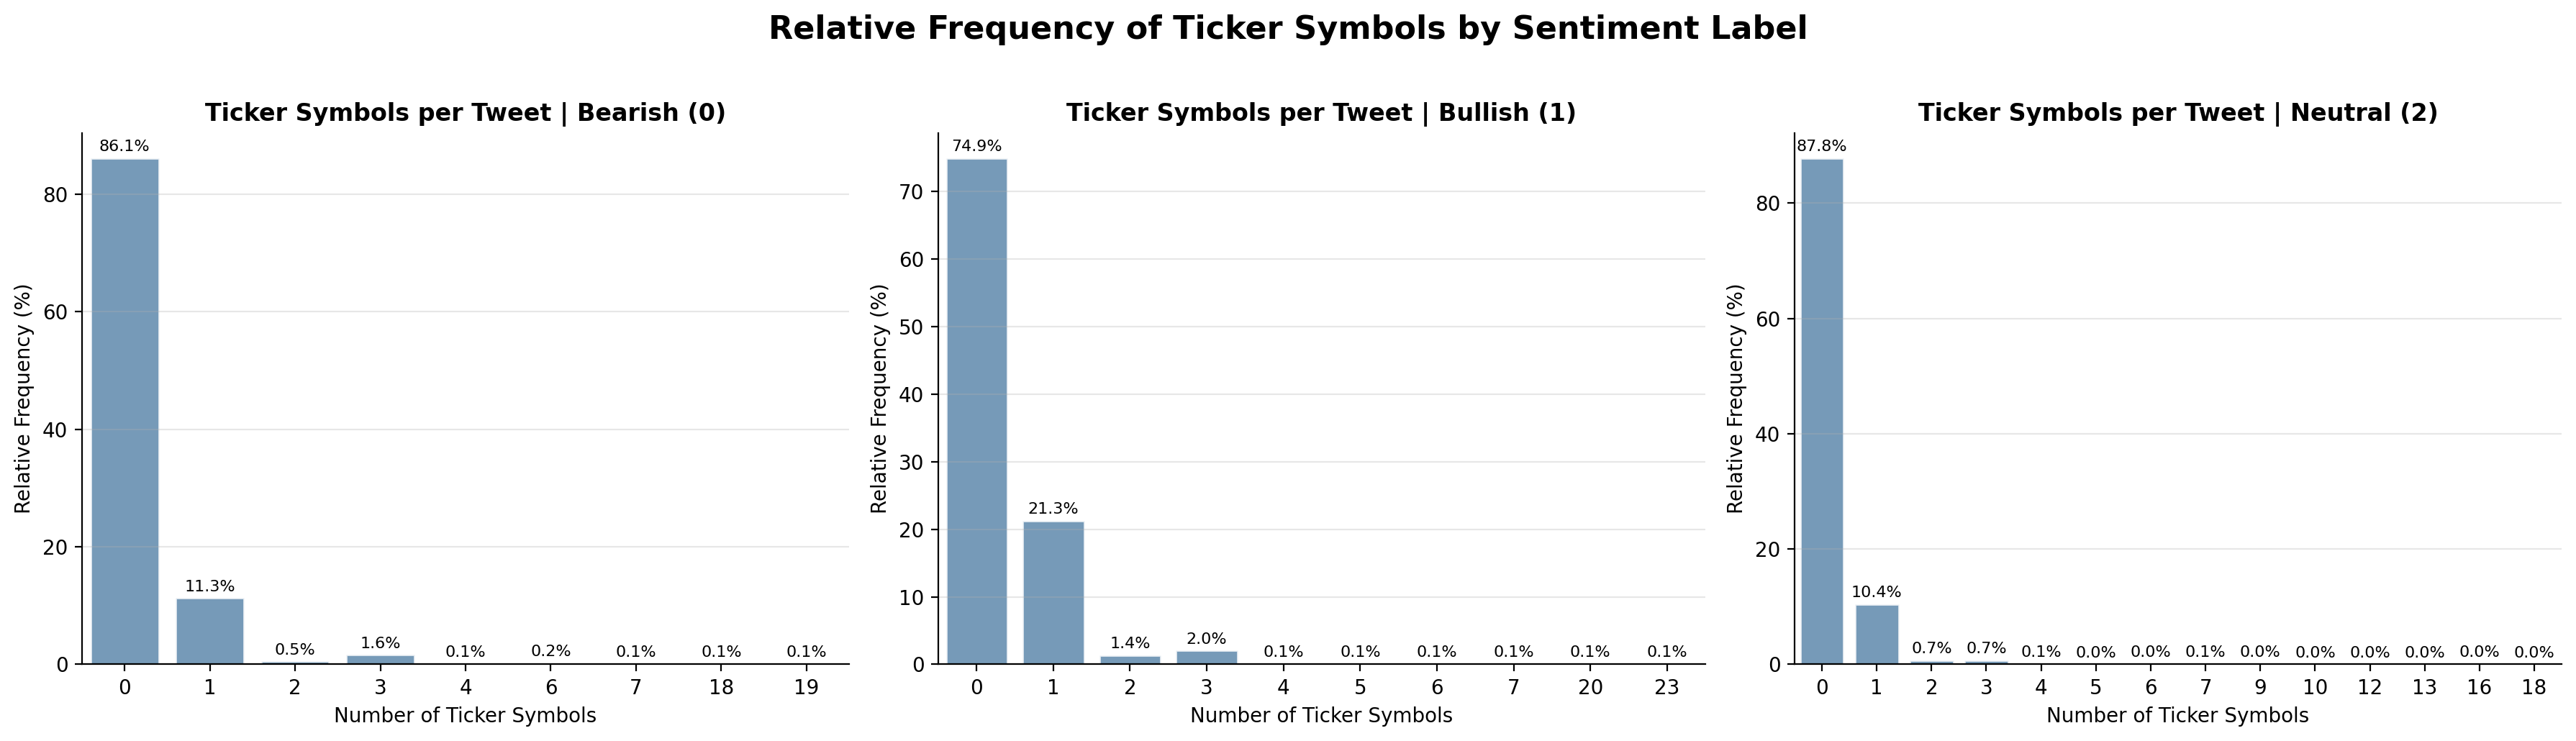

In [14]:
label_map = {0: "Bearish (0)", 1: "Bullish (1)", 2: "Neutral (2)"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, sorted(eda_train["label"].unique())):
    subset = eda_train.query("label == @label")

    rel_freq = subset["num_tickers"].value_counts(normalize=True).sort_index().mul(100)

    sns.barplot(
        x=rel_freq.index,
        y=rel_freq.values,
        color="steelblue",
        edgecolor="white",
        alpha=0.8,
        ax=ax,
    )

    ax.set_title(
        f"Ticker Symbols per Tweet | {label_map[label]}", fontsize=12, fontweight="bold"
    )

    ax.set_xlabel("Number of Ticker Symbols", fontsize=10)
    ax.set_ylabel("Relative Frequency (%)", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)

sns.despine()

fig.suptitle(
    "Relative Frequency of Ticker Symbols by Sentiment Label",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()


The relative frequency distributions reveal that the majority of tweets in all sentiment classes do not contain explicit stock ticker references. However, notable differences emerge when the distributions are normalized by class size. Bullish tweets exhibit the highest proportion of tweets containing a single ticker symbol, with approximately 21.3% of observations including exactly one ticker, compared to 11.3% for Bearish tweets and 10.4% for Neutral tweets. This suggests that positive sentiment is more frequently associated with discussions focused on specific companies.

In contrast, Neutral and Bearish tweets are substantially more likely to contain no ticker references, accounting for 87.8% and 86.1% of observations, respectively. This pattern indicates that these classes rely more heavily on general market commentary, financial news, or broader economic discussions rather than company-specific references.

Tweets containing multiple ticker symbols remain relatively uncommon across all sentiment categories, typically representing less than 2% of observations. Such tweets are likely associated with comparative analyses, sector-level commentary, analyst reports, or market summaries involving several firms simultaneously.

Overall, the results suggest that ticker symbols may provide useful information for sentiment classification when present. In particular, the higher prevalence of ticker mentions within Bullish tweets indicates a stronger connection between positive sentiment and company-specific discussions. Nevertheless, because the majority of tweets across all classes contain no ticker references, ticker-related features should be viewed as complementary signals rather than primary predictors of sentiment.


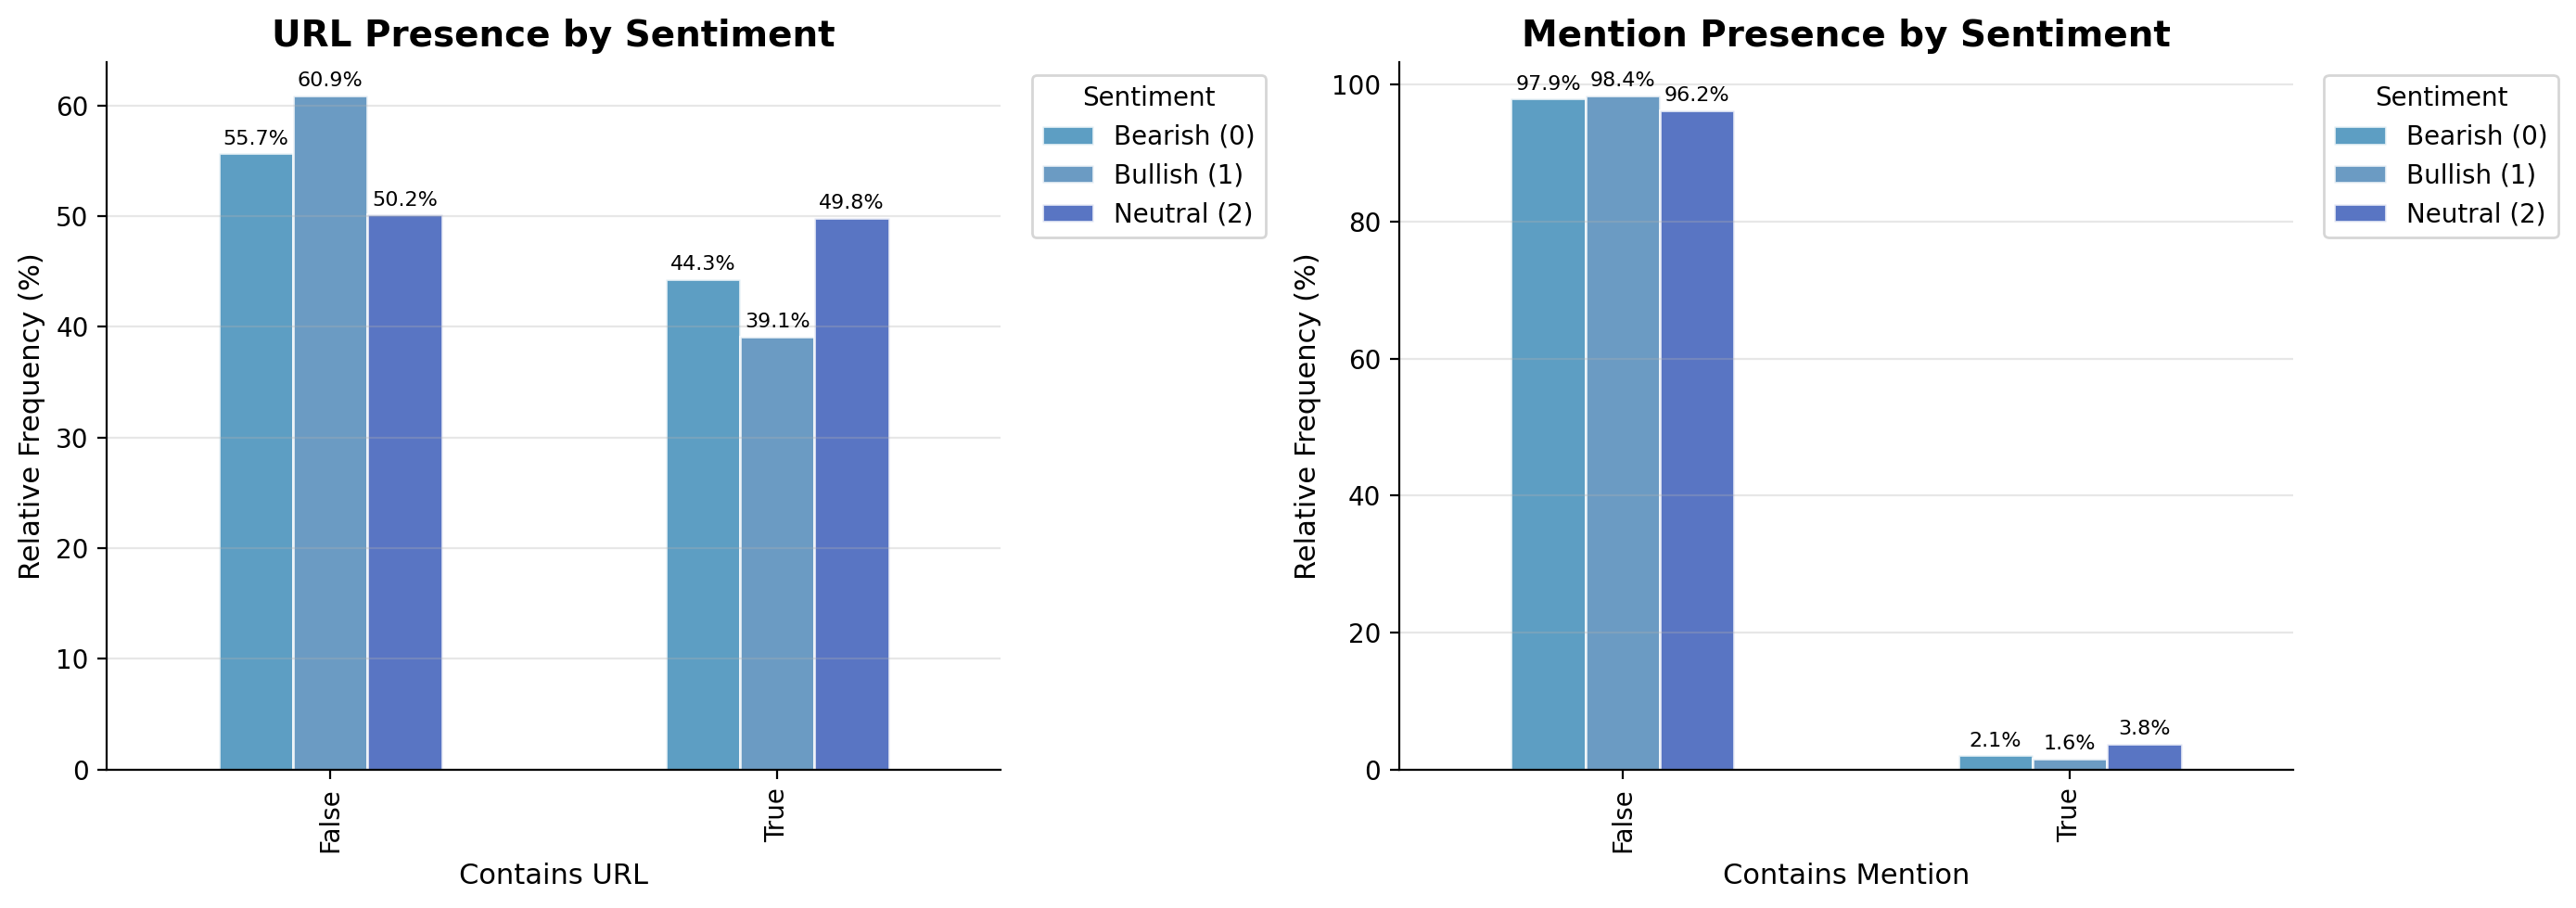

In [15]:
palette = {
    0: "#3586B5",  # Bearish
    1: "steelblue",  # Bullish
    2: "#3052B5",  # Neutral
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

boolean_cols = ["has_url", "has_mention"]
titles = ["URL Presence by Sentiment", "Mention Presence by Sentiment"]
xlabels = ["Contains URL", "Contains Mention"]

for ax, col, title, xlabel in zip(axes, boolean_cols, titles, xlabels):
    rel_freq = pd.crosstab(eda_train[col], eda_train["label"], normalize="columns") * 100

    rel_freq.plot(
        kind="bar",
        ax=ax,
        color=[palette[0], palette[1], palette[2]],
        edgecolor="white",
        alpha=0.8,
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Relative Frequency (%)", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    ax.legend(
        title="Sentiment",
        labels=["Bearish (0)", "Bullish (1)", "Neutral (2)"],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.show()


The distributions of URL and user mention presence reveal distinct patterns across the sentiment classes. Approximately half of all tweets contain an external URL, indicating that the corpus includes a substantial amount of news-sharing and information dissemination activity. Bullish tweets exhibit the highest proportion of URLs, with 60.9% of observations containing a link, compared to 55.7% for Bearish tweets and 50.2% for Neutral tweets. This pattern suggests that positive sentiment is more frequently associated with the sharing of external financial news, analyst reports, or company-specific information.

In contrast, user mentions are extremely rare across all sentiment categories. More than 96% of tweets in each class do not contain a mention, with only 1.6–3.8% of observations including a reference to another user. Neutral tweets exhibit the highest proportion of mentions, although the difference relative to the other classes remains small. The scarcity of mentions indicates that the corpus is primarily composed of informational content rather than conversational interactions between users.

From a machine learning perspective, the presence of URLs may provide a useful auxiliary feature, particularly given its varying prevalence across sentiment classes. However, the near absence of user mentions suggests that this characteristic is unlikely to contribute substantially to sentiment discrimination. Overall, these findings reinforce the notion that sentiment classification in this corpus depends predominantly on the semantic content of the tweets rather than on platform-specific structural features.


# 2. Train/Validation Split


In [16]:
# --- Data splitting --- #
X = train["text"]
y = train["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=73
)

X_test = test["text"]
submission_ids = test["id"]

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Submission IDs:     {len(submission_ids)}")


Training samples:   7634
Validation samples: 1909
Test samples:       2388


# 3. Text Preprocessing


In [17]:
# --- Prepare preprocessing resources and defaults --- #
ensure_nltk_resource("corpora/stopwords", "stopwords")
ensure_nltk_resource("corpora/wordnet", "wordnet")
ensure_nltk_resource("corpora/omw-1.4", "omw-1.4")

english_stop_words = set(stopwords.words("english"))
custom_stopwords = {
    "marketscreener",
    "https",
    "http",
    "www",
    "u",
    "s",
}
stop_words = english_stop_words | custom_stopwords

X_train_clean = X_train.apply(lambda text: preprocess_text(text, stop_words))
X_val_clean = X_val.apply(lambda text: preprocess_text(text, stop_words))
X_test_clean = X_test.apply(lambda text: preprocess_text(text, stop_words))

X_train_clean.head()


1585    instagram is willing to pay for celebrities’ i...
4687    hyperinflation or stagnation, which is worse? ...
6663    major indexes in the red to end record-breakin...
6819                   futures up https://t.co/diz7v5lmvb
9494    $sumrx: gapping up/down: smpl +9% after earnin...
Name: text, dtype: str

In [ ]:
# --- Inspect original versus cleaned text --- #
pd.DataFrame(
    {
        "original": X_train.head(5).values,
        "cleaned": X_train_clean.head(5).values,
    }
)


1585    instagram is willing to pay for celebrities’ i...
4687    hyperinflation or stagnation, which is worse? ...
6663    major indexes in the red to end record-breakin...
6819                                           futures up
9494    $sumrx: gapping up/down: smpl +9% after earnin...
Name: text, dtype: str

In addition to the standard English stopwords provided by NLTK, a small set of domain-specific stopwords was introduced. The objective was to remove terms that primarily reflect the source or structure of the tweets rather than their semantic content or sentiment. The terms `https`, `http`, and `www` were removed because they correspond to URL artifacts generated by links embedded in tweets. Similarly, `marketscreener` was removed because it refers to a news source that appears frequently throughout the corpus and is unlikely to contribute meaningful information for sentiment classification. A conservative approach was maintained when defining the custom stopword list: terms such as _stock_, _shares_, and _new_ were retained because they may still appear in sentiment-bearing expressions such as _stock rises_, _shares plunge_, or _new earnings guidance_.

This strategy minimizes the risk of removing potentially informative financial vocabulary while eliminating source-specific artifacts that are unlikely to improve model performance.


The cleaned text below is the base representation used for downstream variants. Lemmatization and stemming are kept as explicit alternatives so later feature-engineering experiments can compare them against the cleaned baseline.


In [20]:
# --- Apply lemmatization to the cleaned text --- #
X_train_lemma = X_train_clean.apply(lemmatize_text)
X_val_lemma = X_val_clean.apply(lemmatize_text)
X_test_lemma = X_test_clean.apply(lemmatize_text)

X_train_lemma.head()


1585    instagram willing pay celebrities’ igtv produc...
4687    hyperinflation stagnation, worse? ask latin am...
6663             major index red end record-breaking year
6819                                               future
9494    $sumrx: gapping up/down: smpl +9% earnings/gui...
Name: text, dtype: str

In [21]:
# --- Apply stemming to the cleaned text --- #
X_train_stem = X_train_clean.apply(stem_text)
X_val_stem = X_val_clean.apply(stem_text)
X_test_stem = X_test_clean.apply(stem_text)

X_train_stem.head()


1585    instagram will pay celebrities’ igtv product c...
4687      hyperinfl stagnation, worse? ask latin america.
6663                major index red end record-break year
6819                                                futur
9494    $sumrx: gap up/down: smpl +9% earnings/guidanc...
Name: text, dtype: str

# 4. Feature Engineering

This section is reserved for vectorization and feature extraction experiments built on top of `X_train_clean`, `X_train_lemma`, and `X_train_stem`.


# 5. Classification Models

This section is reserved for model training once the feature representations are finalized.


# 6. Evaluation and Analysis

This section is reserved for validation metrics, error analysis, and final comparison tables.
